In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# ML - Linear Regression package (Scikit-Learn)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_csv('Dataset/Real estate.csv')
df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int64  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int64  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB


In [4]:
# house_corr = df.corr()

In [5]:
# sns.heatmap(house_corr, annot=True)

In [6]:
# sns.histplot(df['X3 distance to the nearest MRT station'])

In [7]:
df.columns

Index(['No', 'X1 transaction date', 'X2 house age',
       'X3 distance to the nearest MRT station',
       'X4 number of convenience stores', 'X5 latitude', 'X6 longitude',
       'Y house price of unit area'],
      dtype='object')

In [8]:
features = ['X2 house age', 'X3 distance to the nearest MRT station', 
            'X4 number of convenience stores', 'X5 latitude', 'X6 longitude']
target = 'Y house price of unit area'

In [9]:
X = df[features]
Y = df[target]

In [10]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=1
)

In [11]:
scaler = StandardScaler()

In [12]:
# fit -> Learn and transform -> implement
# Learn -> calculate -> mean and sd -> implement -> implement formula (xi-mean)/sd
X_train_scale = scaler.fit_transform(X_train)

# Implement -> (Xi-mean)/sd
X_test_scale = scaler.transform(X_test)

### Model Selection

In [13]:
model = LinearRegression()

In [14]:
model.fit(X_train_scale, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [15]:
Y_pred = model.predict(X_test_scale)

### Metrics

In [16]:
rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))
r2 = r2_score(Y_test, Y_pred)

In [17]:
print(f'RMSE: {rmse}')
print(f'RMSE %: {rmse/414}')
print(f'R2 Score: {r2}')

RMSE: 6.739791630652899
RMSE %: 0.016279689929113283
R2 Score: 0.700731455305317


### Visualization

In [18]:
min_val = min(Y_test.min(), Y_pred.min())
max_val = max(Y_test.max(), Y_pred.max())

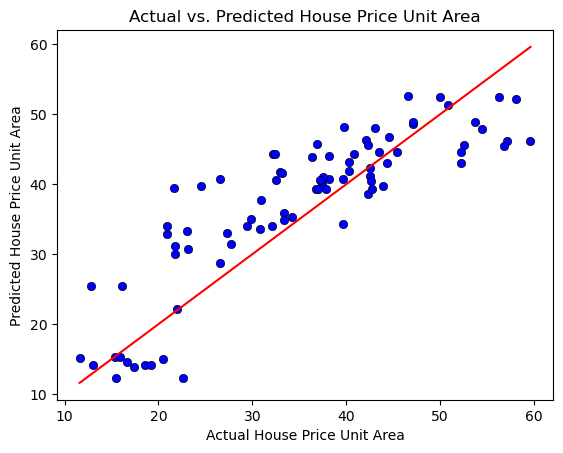

In [19]:
sns.scatterplot(x=Y_test, y=Y_pred, color='blue', edgecolor='black')
plt.plot([min_val, max_val], [min_val, max_val], color='red')
plt.xlabel('Actual House Price Unit Area')
plt.ylabel('Predicted House Price Unit Area')
plt.title('Actual vs. Predicted House Price Unit Area')
plt.show()

### New Data Prediction

In [20]:
input_data = {
    'X2 house age': [20, 5, 50], 
    'X3 distance to the nearest MRT station': [84.87882, 2469.645, 23.445], 
    'X4 number of convenience stores': [3, 1, 4], 
    'X5 latitude': [24.97528, 24.974, 24.96853], 
    'X6 longitude': [121.54915, 121.54464, 121.55391]
}

In [21]:
X_new = pd.DataFrame(input_data)

In [22]:
X_new_scale = scaler.transform(X_new)

In [23]:
Y_new_pred = model.predict(X_new_scale)

In [24]:
X_new['New House Price'] = Y_new_pred

In [25]:
X_new

,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,New House Price
0,20,84.87882,3,24.97528,121.54915,42.225010
1,5,2469.64500,1,24.97400,121.54464,32.370709
2,50,23.44500,4,24.96853,121.55391,34.392755


In [36]:
rf = RandomForestRegressor(n_estimators=1000, random_state=42)
rf.fit(X_train_scale, Y_train)

,n_estimators,1000
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [37]:
rf_pred = rf.predict(X_test_scale)

In [38]:
rmse = np.sqrt(mean_squared_error(Y_test, rf_pred))
r2 = r2_score(Y_test, rf_pred)

In [39]:
print(rmse)
print(r2)

8.299905704595881
0.546147796286589
